# Garlic beliefs and use in the long-COVID / ME-CFS Reddit corpus

**High-level analysis of one pinned second-pass extraction over 1,928 Reddit accounts that
mention garlic, allicin or Kyolic.** Stage 6 of [`DESIGN.md`](DESIGN.md); run provenance in
[`HANDOFF.md`](HANDOFF.md).

Two folk systems share the word *garlic* in this community. One treats it as an
antimicrobial and cardiovascular intervention to be taken deliberately; the other treats it
as a trigger food to be named on a list and avoided. A cohort built from the first pass's
`treatment_outcome` field would have kept the first group and dropped most of the second.
This extraction was built to hold both, so the belief payload is never gated on whether the
author actually swallowed anything.

## What every number below is

A **share of extractable reports**, at the **reporter** level, with its denominator stated.
"Reporter" means a Reddit account, not a verified person.

## What no number below is

| Not this | Why |
|---|---|
| Efficacy or a causal effect | Self-selected posters describing themselves; no control, no exposure ascertainment |
| Incidence or prevalence of anything | The denominator is people whose *text* yielded an extractable claim |
| A dose-response relationship | Explicitly out of scope (DESIGN §8). Linkage and n are too thin, and the amounts are not commensurable |
| Evidence that garlic helped or harmed anyone | `helped` is a label on a sentence, not an outcome measurement |
| A count of people who avoid garlic | A high-histamine food list is not personal avoidance; the schema separates them |

`not_stated` is silence, not denial. Only `explicit_none` is a denial. Timestamps are not
loaded and chronology is never inferred from them.

### Two prior results that constrain how this is read

1. **The extractor's own reliability is measured here, not assumed.** The first-pass JSON
   records this corpus already had were unstable on a repeated pass (36.5% field-set
   agreement, 58.8% value agreement). §2 and §7 hold this run to the same test rather than
   exempting it.
2. **GATE 4 check (b) did not clear.** A blind labelling pass on 80 sampled windows agreed
   with the model on only **5 of 12** rows where either party assigned `food_list`,
   `avoidance` or `culinary` — the three values this study leans on hardest. The sample was
   too small to declare confusion or to clear it, and human adjudication was deferred.
   Every `food_list` / `avoidance` / `culinary` figure below is therefore **provisional**,
   and is marked as such where it appears.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

GARLIC_DIR = next(c for p in (Path.cwd(), *Path.cwd().parents)
                  for c in (p, p / "studies/garlic")
                  if (c / "garlic.py").is_file())
sys.path.insert(0, str(GARLIC_DIR))
import garlic as G

G.apply_style(plt)
pd.set_option("display.width", 110, "display.max_columns", 30)

# The run is pinned by full id. Three stale specs live in the same database file
# and their claims must never be merged with these.
f = G.load_frames(run_id=G.RUN_ID)

# Printed untruncated: a run id or database checksum that ends in "..." is not
# provenance.
print(G.provenance_table(f).to_string(index=False, max_colwidth=90))

                        item                                                                                      value
                    database                                                                     garlic_pharmacology.db
            database SHA-256                           7caae438b3512ea0cb4a59f2956d3417b0b7abfde34a234dfab3e7b3d32eb4f0
             run ID (pinned)                           c05891b6ecad47900230eb606afbb230a9867fc9f41d1d2b88ec0292a05b03df
                 run created                                                           2026-08-12T23:40:00.979171+00:00
                       model                                                                 deepseek/deepseek-v4-flash
         provider / base URL                                                         openai / https://openrouter.ai/api
                    sampling                                temperature 0.0, max_tokens 32,768, reasoning_effort medium
HTTP timeout (not in run_id)            

---
# 1. What the extraction produced, and the denominators it licenses

The cohort is every non-bot account matching the FTS query `garlic OR allicin OR kyolic`,
independent of whether the first pass ever coded them as taking anything. Retrieval is
regex; identity, speech act and attribution are all model-labelled.

In [2]:
units = f.units
complete = units[units.status == "complete"]
claims = f.claims

pipeline = pd.DataFrame([
    {"stage": "cohort members (accounts)", "n": len(f.members)},
    {"stage": "evidence windows (paragraph neighbourhoods)", "n": int(units.windows.sum())},
    {"stage": "characters sent", "n": int(units.characters.sum())},
    {"stage": "planned units", "n": len(units)},
    {"stage": "units complete", "n": len(complete)},
    {"stage": "units failed (retries exhausted)",
     "n": int((units.status == "failed").sum())},
    {"stage": "complete units yielding zero claims",
     "n": len(complete) - complete.unit_key.isin(claims.unit_key).sum()},
    {"stage": "claims (garlic events)", "n": len(claims)},
    {"stage": "  of which included (analysis membership)", "n": int(claims.included.sum())},
    {"stage": "  of which excluded (inspectable denominator)",
     "n": int((~claims.included).sum())},
])
pipeline["n"] = pipeline["n"].map("{:,}".format)
display(pipeline.set_index("stage"))

,n
stage,
cohort members (accounts),"1,928"
evidence windows (paragraph neighbourhoods),"3,873"
characters sent,"2,058,992"
planned units,"1,996"
units complete,"1,990"
units failed (retries exhausted),6
complete units yielding zero claims,24
claims (garlic events),"3,723"
of which included (analysis membership),"2,911"


`included` is analysis membership and gates nothing. A separate predicate,
`use_payload_allowed` (`speech_act == actual_use` **and** `subject == self`), is the only
thing that lets an event carry a preparation, a dose, an effect or an adverse event. Keeping
them apart is what stops a trigger-food list from acquiring an adverse-event status.

Each cut below is computed over the reporters *eligible* for it, and the eligible sets are
different sizes. These four denominators are fixed by the schema, not chosen after looking
at the results.

In [3]:
REPORTERS = complete.reporter.nunique()          # accounts whose text was processed
belief = claims[claims.polarity.notna()]
use = claims[claims.use_payload_allowed]

denoms = pd.DataFrame([
    {"cut": "speech-act mix",
     "denominator": "accounts with ≥1 complete unit", "n": REPORTERS},
    {"cut": "(accounts that yielded ≥1 claim)",
     "denominator": "— shown for contrast; 20 accounts produced none",
     "n": claims.reporter.nunique()},
    {"cut": "belief polarity, mechanism mix, cited authority",
     "denominator": "accounts with ≥1 belief-payload event", "n": belief.reporter.nunique()},
    {"cut": "preparation, dose, effect, adverse event",
     "denominator": "accounts with ≥1 use-payload event", "n": use.reporter.nunique()},
    {"cut": "effect direction",
     "denominator": "accounts with ≥1 extractable effect record",
     "n": f.effects.reporter.nunique()},
]).set_index("cut")
display(denoms)

print(f"reporters carrying both a belief payload and a use payload: "
      f"{len(set(belief.reporter) & set(use.reporter)):,}")
print("\nRows per frame:")
display(pd.DataFrame([
    {"frame": k, "rows": len(v), "reporters": v.reporter.nunique()}
    for k, v in [("claims", claims), ("mechanisms (long)", f.mechanisms),
                 ("effects", f.effects), ("adverse events", f.adverse),
                 ("doses", f.doses)]]).set_index("frame"))

,denominator,n
cut,,
speech-act mix,accounts with ≥1 complete unit,1927
(accounts that yielded ≥1 claim),— shown for contrast; 20 accounts produced none,1907
"belief polarity, mechanism mix, cited authority",accounts with ≥1 belief-payload event,950
"preparation, dose, effect, adverse event",accounts with ≥1 use-payload event,640
effect direction,accounts with ≥1 extractable effect record,301


reporters carrying both a belief payload and a use payload: 438

Rows per frame:


,rows,reporters
frame,,
claims,3723,1907
mechanisms (long),1184,607
effects,569,301
adverse events,172,106
doses,328,193


---
# 2. How much to trust the extractor

Reported before any substantive result, because it bounds everything that follows.

In [4]:
display(G.attempt_summary(f))
display(G.cost_by_status(f).round(4))

,value
metric,
attempts,"6,087"
accepted,"1,990"
validation_failed,"3,994"
transport_failed,103
cache hits,0
billing_uncertain (excluded from cost),72
input tokens,"23,486,570"
output tokens,"20,917,167"
of which reasoning,"17,815,936"


,status,attempts,cost,share of spend
0,validation_failed,3994,4.5551,0.6513
1,accepted,1990,2.1803,0.3117
2,transport_failed,31,0.2586,0.0370


**Two thirds of the money went to rejected attempts.** That is not a billing curiosity, it
is the shape of the prompt-versus-guard mismatch: the model's first instinct on the three
required grounding quotes (`speech_act`, `subject`, `exposure_status`) is to write a
taxonomy gloss — a word like *author* or *listed* — which the 0.5 bag-of-words floor
rejects because those words are not in the window. Retries then copy source tokens until it
passes. 531 of the 1,990 complete units were accepted on attempt 1; the other 1,459 needed at
least one retry.

`HANDOFF.md` and the ops report quote **534** here. Both are right under different
definitions: 531 units were accepted on their *first* attempt, and 534 units accrued *zero
validation failures* — the extra 3 hit a transport error, then were accepted on retry
without ever failing validation. The chart below uses the stricter 531.

The floor stayed at 0.5 throughout and was never lowered. Six units exhausted their retries
and were dropped rather than rescued with loosened flags.

*Reconciling with [`docs/garlic_probe_run_report.md`](../../docs/garlic_probe_run_report.md)
§5:* that report counts an attempt under every error head it matches, so its categories
overlap and do not sum. The table below assigns each attempt to exactly one category on
first match, so it partitions and sums to the total. `wrong_source_reference` here merges
the report's three separate source-reference heads (`source_type`, ID/type mismatch, source
not in unit: 270 + 107 + 89 = 466), and splits the report's single use-payload head (112)
into the two opposite defects it conflates: an ineligible event carrying use-payload fields
(83) versus an eligible event missing its required `preparation` (29).

,status,failure,attempts,units
0,transport_failed,timeout,41,40
1,transport_failed,null_content,31,22
2,transport_failed,connection_error,28,27
3,transport_failed,other_schema_error,3,3
4,validation_failed,quote_not_grounded,3330,1396
5,validation_failed,wrong_source_reference,466,364
6,validation_failed,use_payload_on_ineligible_event,83,64
7,validation_failed,other_schema_error,35,34
8,validation_failed,use_payload_missing_preparation,29,24
9,validation_failed,schema_extra_inputs,22,20


complete units accepted on attempt 1:        531 of 1,990
complete units with zero validation failures: 534 of 1,990   ← the figure quoted in HANDOFF.md


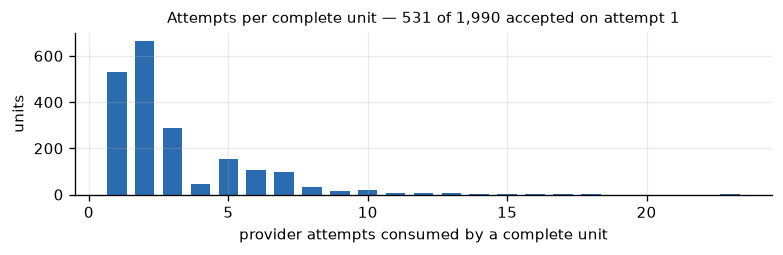

In [5]:
display(G.failure_table(f))

# Restricted to complete units: a failed unit's attempt count measures how many
# times it was retried before being abandoned, which is a different quantity.
per_unit = (f.attempts[f.attempts.unit_key.isin(complete.unit_key)]
            .groupby("unit_key").size())
first_pass = int((per_unit == 1).sum())
no_validation_failure = int(
    complete.unit_key.isin(
        set(complete.unit_key)
        - set(f.attempts.loc[f.attempts.status == "validation_failed", "unit_key"])
    ).sum())
print(f"complete units accepted on attempt 1:        {first_pass:,} of {len(per_unit):,}")
print(f"complete units with zero validation failures: {no_validation_failure:,} "
      f"of {len(per_unit):,}   ← the figure quoted in HANDOFF.md")

fig, ax = plt.subplots(figsize=(6.6, 2.2))
counts = per_unit.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=G.COLORS["accent"], width=0.7)
ax.set_xlabel("provider attempts consumed by a complete unit")
ax.set_ylabel("units")
ax.set_title(f"Attempts per complete unit — {first_pass:,} of {len(per_unit):,} "
             f"accepted on attempt 1", fontsize=9)
plt.tight_layout(); plt.show()

## 2.1 How much source text the model actually copied

DESIGN §7.5 specifies evidence quotes as **short paraphrases**, and the validator enforces
only a 0.5 bag-of-words overlap floor — which a verbatim span passes trivially. Nothing in
the pipeline measured which one the model actually produced, so it is measured here against
the window text.

Two distinct populations of model-written strings are measured, because they are governed
differently:

* the `*_quote` **evidence anchors**, which carry the 0.5 floor;
* the free-text **payload fields** — `doses.raw_text`, `adverse_events.raw_event`,
  `effects.target`, `duration.raw_text` — which are not evidence anchors and carry **no
  grounding floor at all**. Nothing ever constrained how literal these are, and DESIGN §7.3
  actively asks `raw_text` to preserve the author's amount string.

evidence anchors (0.5 grounding floor applies):


,strings,median_words,contiguous_verbatim,mean_overlap,full_overlap
field_path,,,,,
exposure_status,3723,6.0,0.343,0.812,0.545
speech_act,3723,8.0,0.399,0.890,0.622
subject,3723,6.0,0.397,0.829,0.598
effects,569,6.0,0.705,0.979,0.900
doses,328,5.0,0.817,0.979,0.918
cited_authority,210,7.0,0.410,0.933,0.686
adverse_events,172,6.0,0.814,0.987,0.930
adverse_event_status,145,6.0,0.655,0.947,0.786
duration,98,4.0,0.847,0.978,0.918


free-text payload fields (NO grounding floor):


,strings,median_words,contiguous_verbatim,mean_overlap,full_overlap
field_path,,,,,
doses.raw_text,328,4.0,0.905,0.995,0.982
effects.target,253,2.0,0.545,0.790,0.664
adverse_events.raw_event,172,3.0,0.645,0.888,0.756
duration.raw_text,82,3.0,0.951,0.989,0.963


quotes: 12,691 strings, 41.9% contiguous verbatim
free-text fields: 835 strings, 74.7% contiguous verbatim


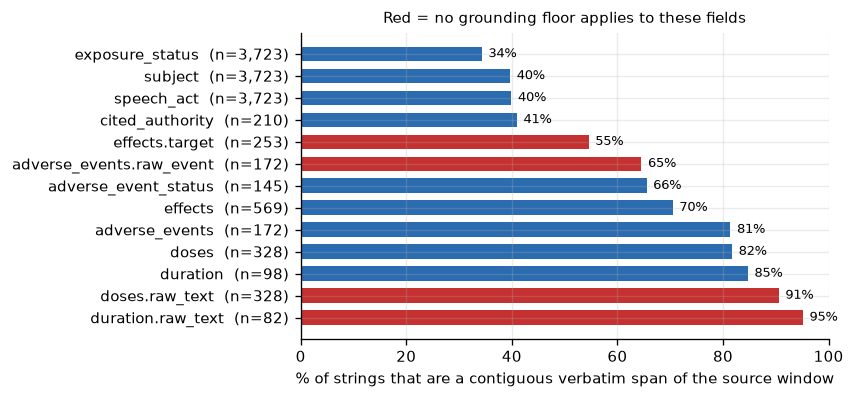

In [6]:
qc = G.quote_character()
ft = G.freetext_character()
print("evidence anchors (0.5 grounding floor applies):")
display(qc.round(3))
print("free-text payload fields (NO grounding floor):")
display(ft.round(3))

for name, tbl in [("quotes", qc), ("free-text fields", ft)]:
    weighted = (tbl.contiguous_verbatim * tbl.strings).sum() / tbl.strings.sum()
    print(f"{name}: {int(tbl.strings.sum()):,} strings, "
          f"{weighted:.1%} contiguous verbatim")

fig, ax = plt.subplots(figsize=(7.2, 3.4))
both = pd.concat([
    qc.assign(kind="evidence anchor (floored)"),
    ft.assign(kind="free-text payload (ungoverned)"),
]).sort_values("contiguous_verbatim")
colors = [G.COLORS["accent"] if k.startswith("evidence") else G.COLORS["worsened"]
          for k in both.kind]
y = np.arange(len(both))[::-1]
ax.barh(y, 100 * both.contiguous_verbatim, height=0.66, color=colors)
ax.set_yticks(y, [f"{i}  (n={int(n):,})" for i, n in zip(both.index, both.strings)])
for yi, v in zip(y, 100 * both.contiguous_verbatim):
    ax.annotate(f"{v:.0f}%", (v, yi), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=7.5)
ax.set_xlim(0, 100)
ax.set_xlabel("% of strings that are a contiguous verbatim span of the source window")
ax.set_title("Red = no grounding floor applies to these fields", fontsize=9)
plt.tight_layout(); plt.show()

**42% of all 12,691 evidence quotes are exact contiguous spans of the source text, and 62%
have complete bag-of-words overlap.** The split across fields is systematic rather than
random: the three mandatory grounding quotes sit near 34–40% verbatim, because those are the
fields the model first tried to gloss and then had to re-copy under retry pressure. The
payload quotes are roughly twice as literal — `duration` 85%, `doses` 82%,
`adverse_events` 81%, `effects` 71% — and clear 90–93% on full overlap, because an amount or
a side effect has few faithful paraphrases at six words.

**The ungoverned free-text fields are more verbatim still: 75% across 835 strings, and
`doses.raw_text` is 91% contiguous — the most literal field in the entire extraction.**
This is the opposite of the intuition that a model-written summary field is safer than a
quote. It follows directly from the incentives: the quote fields at least had a paraphrase
instruction pushing against copying, and `raw_text` had an explicit instruction to preserve
what the author wrote.

Three consequences, none cosmetic:

* The paraphrase contract is **not** a privacy control, and the 0.5 floor was never intended
  as one — it is a fabrication guard. Any table printing these strings reproduces Reddit
  text verbatim a large fraction of the time. This notebook therefore keeps every one of
  them out of the aggregates and confines them to §8.
* **`effects.target` is the one free-text field this notebook does compute on**, in §5.3.
  It is 55% verbatim, so it is never displayed as text: it is mapped through a closed
  symptom vocabulary in the loader and only the class counts are shown.
* GATE 4 check (a) — 91.8% grounding — measured whether quotes *support* their field. It was
  never evidence that they were paraphrases and should not be cited as such.

---
# 3. Who is saying what about garlic

The speech act is the study's primary axis. It is model-labelled on each event, never
inferred from a keyword. `food_list` — garlic named on a trigger, safe or high-histamine
list with no personal dosing — is the modal form of anti-garlic speech and was the main
reason this study could not reuse the psychedelic contract.

Bars overlap: one account can produce several speech acts and is counted under each.

,value,reporters,denominator,rate,ci_lo,ci_hi,headline,regex prior,vs prior
0,actual_use,650,1927,0.337,0.317,0.359,True,156.0,494.0
1,culinary,408,1927,0.212,0.194,0.231,True,201.0,207.0
2,food_list,355,1927,0.184,0.168,0.202,True,536.0,-181.0
3,recommendation,297,1927,0.154,0.139,0.171,True,NaN,NaN
4,mechanism_belief,179,1927,0.093,0.081,0.107,True,NaN,NaN
5,other,166,1927,0.086,0.074,0.100,True,NaN,NaN
6,question,164,1927,0.085,0.073,0.098,True,NaN,NaN
7,avoidance,109,1927,0.057,0.047,0.068,True,37.0,72.0
8,planned_or_considered,96,1927,0.050,0.041,0.060,True,NaN,NaN
9,warning,15,1927,0.008,0.005,0.013,False,NaN,NaN


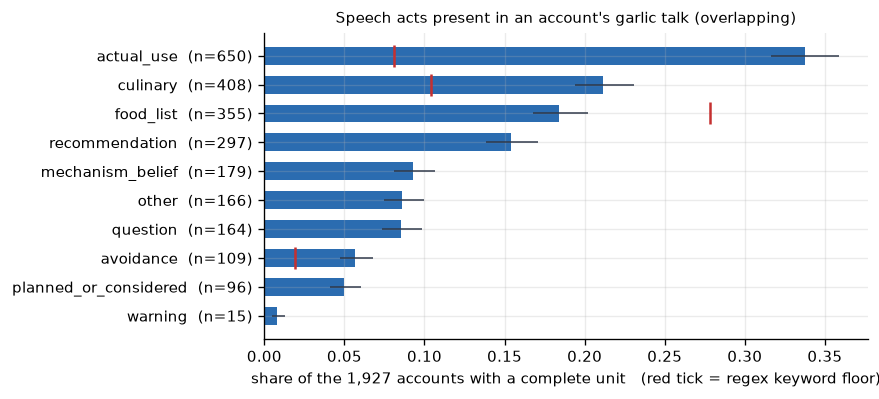

In [7]:
sa = G.reporter_matrix(f, "speech_act", G.SPEECH_ACTS)
sa_rates = G.rate_table(sa, denominator=REPORTERS, priors=G.PRIORS["speech_act"])
display(sa_rates.round(3))

fig, ax = plt.subplots(figsize=(7.4, 3.4))
G.ci_bars(ax, sa_rates.value.tolist(), sa_rates.rate.tolist(),
          sa_rates.ci_lo.tolist(), sa_rates.ci_hi.tolist(),
          sa_rates.reporters.tolist(), color=G.COLORS["accent"])
prior = [G.PRIORS["speech_act"].get(v) for v in sa_rates.value]
y = np.arange(len(sa_rates))[::-1]
for yi, p in zip(y, prior):
    if p:
        ax.scatter([p / G.PRIORS["authors"]], [yi], marker="|", s=180,
                   color="#c53030", zorder=5)
ax.set_xlabel(f"share of the {REPORTERS:,} accounts with a complete unit"
              "   (red tick = regex keyword floor)")
ax.set_title("Speech acts present in an account's garlic talk (overlapping)", fontsize=9)
plt.tight_layout(); plt.show()

### Reading this against the keyword floors

The red ticks are regex lower bounds over the same 1,928 accounts (DESIGN §4). They are
recall floors, not labels, so the model exceeding them is expected — but the *direction* of
each gap is informative.

* **`actual_use`, 650 accounts (33.7%)**, against a first-person regex floor of 156. A
  four-fold gap is what a model-labelled identity field is supposed to buy over
  `I take/eat/tried garlic`, which cannot see "been doing a clove every morning since
  March". This is the single most important reason the study was not built on regex.
* **`food_list`, 355 accounts (18.4%)**, *below* the 536-account food-list keyword prior.
  The regex fired on any onion/tomato/histamine list co-occurring in a garlic document; the
  model apparently declined a large share of those as not actually naming garlic on a list.
  That is the expected direction of correction, but it is unverified — and it is exactly
  the value GATE 4 (b) failed to clear.
* **`culinary`, 408 accounts (21.2%)**, *double* the 201-account culinary-only prior.
  Ordinary cooking talk is a fifth of this cohort. DESIGN predicted it would not be a swamp
  and chose to pay for it rather than regex-drop it; that call looks right, and the
  `included = false` rows are retained as an inspectable denominator rather than discarded.
* **`avoidance`, 109 accounts (5.7%)**. This sits between the 10–37 account regex band and
  a discredited earlier estimate of 302 that had counted any low-histamine co-mention as
  avoidance. Landing in between is reassuring but is not validation: n = 109 clears the
  n ≥ 30 headline floor, yet GATE 4 (b) found `food_list` ↔ `avoidance` swapping in **both**
  directions on a 12-row sample. Treat 109 as provisional.

## 3.1 Most accounts do one thing; a minority do several

Mixed-act reporters were anticipated in the design, and the overlap between the food-list
population and the actual-use population is a substantive finding rather than a coding
error: the same person can warn that garlic is high-histamine and separately report taking
an allicin capsule.

In [8]:
n_acts = (claims.groupby("reporter").speech_act.nunique()
          .reindex(complete.reporter.unique()).fillna(0).astype(int))
display(n_acts.value_counts().sort_index().rename("accounts")
        .rename_axis("distinct speech acts").to_frame())

pairs = ["actual_use", "food_list", "avoidance", "culinary"]
sets = {p: set(claims[claims.speech_act == p].reporter) for p in pairs}
overlap = pd.DataFrame(
    [[len(sets[a] & sets[b]) if a != b else len(sets[a]) for b in pairs] for a in pairs],
    index=pairs, columns=pairs)
print("Accounts appearing in both speech acts (diagonal = total):")
display(overlap)

,accounts
distinct speech acts,
0,20
1,1557
2,226
3,85
4,28
5,7
6,2
7,1
9,1


Accounts appearing in both speech acts (diagonal = total):


,actual_use,food_list,avoidance,culinary
actual_use,650,43,11,33
food_list,43,355,20,29
avoidance,11,20,109,6
culinary,33,29,6,408


**43 accounts produce both a food list and a self-reported use event, and 11 produce both
personal avoidance and self-reported use.** Neither is a contradiction to be resolved. The
schema stores source-level events, so a person who ate raw garlic for a month and later put
it on a trigger list stays two events, and both survive into the counts. A first-pass
`treatment_outcome` extraction would have collapsed each of these accounts to one verdict.

---
# 4. The two folk systems

The belief payload — polarity and mechanism — attaches to **any** included event, including
`actual_use`. That is deliberate: stripping the mechanism from people who actually took the
stuff would sever "I crush it and wait for the allicin, to break up biofilm" into two
half-events and make the central question unanswerable for the people best placed to
answer it.

In [9]:
pol = G.reporter_matrix(f, "polarity", G.POLARITIES)
BELIEF_N = belief.reporter.nunique()
pol_rates = G.rate_table(pol, denominator=BELIEF_N)
display(pol_rates.round(3))

multi = belief.groupby("reporter").polarity.nunique()
print(f"accounts whose garlic events carry more than one polarity: "
      f"{int((multi > 1).sum()):,} of {BELIEF_N:,} ({(multi > 1).mean():.1%})")

,value,reporters,denominator,rate,ci_lo,ci_hi,headline
0,pro_use,655,950,0.689,0.659,0.718,True
1,anti_use,302,950,0.318,0.289,0.348,True
2,mixed,59,950,0.062,0.048,0.079,True
3,unclear,32,950,0.034,0.024,0.047,True


accounts whose garlic events carry more than one polarity: 78 of 950 (8.2%)


Pro-use speech outnumbers anti-use roughly two to one among accounts with any belief event,
and **78 accounts (8.2%) disagree with themselves** across their own events. Reported as its
own count rather than resolved to a per-person verdict, per DESIGN §8.

## 4.1 Which mechanism belongs to which system

This is the cut the study was built for. Each cell counts distinct accounts asserting that
mechanism on an event of that polarity, so an account can appear in more than one row.

polarity,pro_use,anti_use,mixed,unclear,accounts (any polarity),regex prior
mechanism,,,,,,
antimicrobial,195,8,12,5,214,227
gut_or_biofilm,73,12,4,1,88,259
immune,77,5,3,4,87,110
cardiovascular_or_bleeding,126,15,16,8,149,70
herx_or_dieoff,9,0,1,4,14,39
histamine_or_mcas_trigger,7,31,1,3,38,198
allium_intolerance,2,67,3,2,72,0
other,67,38,3,2,110,0


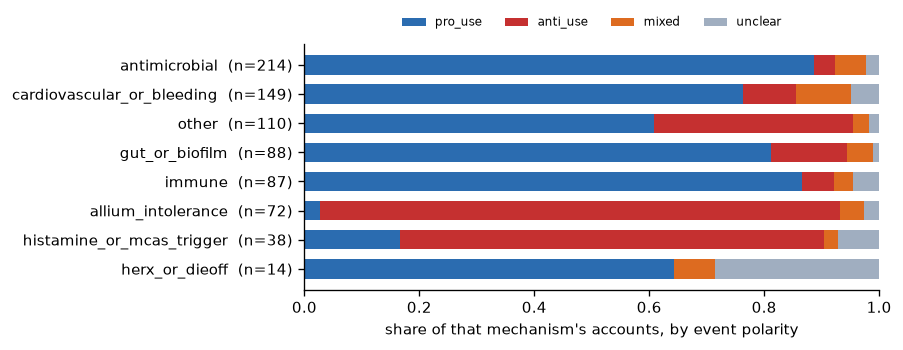

In [10]:
mech = f.mechanisms[f.mechanisms.polarity.notna()]
rep_mech = mech.drop_duplicates(["reporter", "mechanism", "polarity"])
ct = (pd.crosstab(rep_mech.mechanism, rep_mech.polarity)
      .reindex(index=list(G.MECHANISMS), columns=list(G.POLARITIES), fill_value=0))
ct["accounts (any polarity)"] = mech.groupby("mechanism").reporter.nunique()
ct["regex prior"] = pd.Series(G.PRIORS["mechanism"])
display(ct.fillna(0).astype(int))

share = ct[list(G.POLARITIES)]
share = share.div(share.sum(axis=1), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(7.6, 3.0))
left = np.zeros(len(share))
order = ct.sort_values("accounts (any polarity)").index
share = share.loc[order]
for p in G.POLARITIES:
    ax.barh(np.arange(len(share)), share[p], left=left, height=0.66,
            color=G.COLORS[p], label=p)
    left += share[p].to_numpy()
ax.set_yticks(np.arange(len(share)),
              [f"{m}  (n={int(ct.loc[m, 'accounts (any polarity)'])})" for m in order])
ax.set_xlim(0, 1); ax.set_xlabel("share of that mechanism's accounts, by event polarity")
ax.legend(fontsize=7, ncol=4, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False)
ax.grid(False)
plt.tight_layout(); plt.show()

### The split is nearly clean, and it is not the split the design predicted

The mechanisms sort themselves into two almost non-overlapping blocs:

| Bloc | Mechanisms | Character |
|---|---|---|
| **Pro-use** | `antimicrobial` (195/214 accounts pro), `immune` (77/87), `gut_or_biofilm` (73/88), `cardiovascular_or_bleeding` (126/149), and `herx_or_dieoff` (9/14, below the floor) | Garlic as an agent that does something to a pathogen, a biofilm, or a blood vessel |
| **Anti-use** | `allium_intolerance` (67/72 accounts anti), `histamine_or_mcas_trigger` (31/38) | Garlic as a substance the body reacts badly to |

`allium_intolerance` is the sharpest: 67 of its 72 accounts assert it on an anti-use event
and 2 on a pro-use one. `antimicrobial` mirrors it. Almost nobody is arguing *about* a
mechanism — the two camps are asserting different mechanisms and largely not addressing
each other.

**Two departures from what DESIGN §4 expected, both worth flagging:**

1. **The anti-garlic system is smaller and differently shaped than the priors suggested.**
   The design anticipated histamine/MCAS as the anti-use engine on the strength of a
   198-account co-mention count. The model finds only 38 accounts asserting
   `histamine_or_mcas_trigger` as a mechanism, and puts more anti-use weight on plain
   `allium_intolerance` (72). Co-mentioning "low histamine" in a garlic post is evidently
   not the same as claiming garlic triggers histamine — which was the exact error behind
   the discredited 302-account avoidance figure.
2. **Cardiovascular talk is much larger than expected, and it is mostly pro-use.**
   DESIGN §4.5 logged 70 accounts with bleeding/anticoagulant language and treated it as a
   caution register. The extraction finds **149 accounts**, of which **126 assert it on a
   pro-use event** — blood pressure, circulation, vasodilation, clotting. This is not a
   warning about garlic thinning your blood; in a long-COVID community with an active
   microclot theory, it is a *reason to take it*. That reframing was not in the design's
   prior and is the most substantive new thing in this cut.

`gut_or_biofilm`, the mechanism the design put at the centre of the pro-use system, is real
but modest at 88 accounts — well under its 259-account keyword prior, and smaller than the
cardiovascular story it was expected to dominate.

---
# 5. Among people who report actually using it

Everything in this section is restricted to `use_payload_allowed` events — `speech_act =
actual_use` **and** `subject = self`. Hearsay ("garlic helped my friend") is a belief and
never reaches these frames.

,value,reporters,denominator,rate,ci_lo,ci_hi,headline,regex prior,vs prior
0,unspecified_form,330,640,0.516,0.477,0.554,True,NaN,NaN
1,raw_clove,168,640,0.262,0.230,0.298,True,334.0,-166.0
2,allicin_supplement,104,640,0.162,0.136,0.193,True,215.0,-111.0
3,other,51,640,0.080,0.061,0.103,True,NaN,NaN
4,cooked_culinary,39,640,0.061,0.045,0.082,True,NaN,NaN
5,crushed_wait_allicin,33,640,0.052,0.037,0.072,True,114.0,-81.0
6,aged_extract_kyolic,22,640,0.034,0.023,0.051,False,37.0,-15.0
7,tea,21,640,0.033,0.022,0.050,False,8.0,13.0
8,oil,10,640,0.016,0.009,0.029,False,20.0,-10.0
9,topical_or_otic,9,640,0.014,0.007,0.027,False,69.0,-60.0


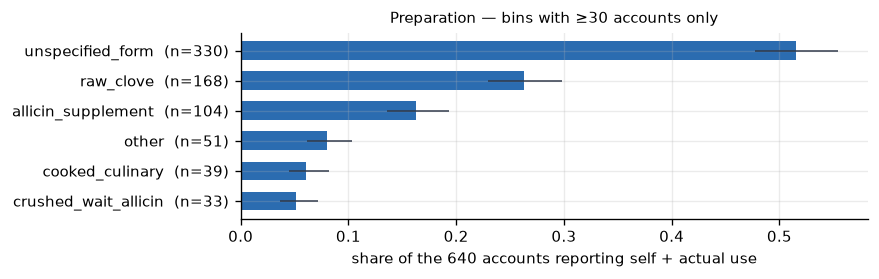

Collapsed (reporter n < 30, coded but not headlined): aged_extract_kyolic 22, tea 21, oil 10, topical_or_otic 9, black_garlic 8


In [11]:
USE_N = use.reporter.nunique()
prep = G.reporter_matrix(f, "preparation", G.PREPARATIONS)
prep_rates = G.rate_table(prep, denominator=USE_N, priors=G.PRIORS["preparation"])
display(prep_rates.round(3))

head = prep_rates[prep_rates.headline]
fig, ax = plt.subplots(figsize=(7.4, 2.4))
G.ci_bars(ax, head.value.tolist(), head.rate.tolist(), head.ci_lo.tolist(),
          head.ci_hi.tolist(), head.reporters.tolist(), color=G.COLORS["accent"])
ax.set_xlabel(f"share of the {USE_N:,} accounts reporting self + actual use")
ax.set_title(f"Preparation — bins with ≥{G.MIN_REPORTERS} accounts only", fontsize=9)
plt.tight_layout(); plt.show()

collapsed = prep_rates[~prep_rates.headline]
print(f"Collapsed (reporter n < {G.MIN_REPORTERS}, coded but not headlined): "
      + ", ".join(f"{r.value} {r.reporters}" for r in collapsed.itertuples()))

**The single largest preparation bin is `unspecified_form` — 330 of 640 use-reporting
accounts, 52%.** More than half of the people who say they take garlic do not say in what
form. That is the honest headline of this cut, and it caps how much the rest of it can
carry.

Among those who do specify, the mix is **raw cloves (168) and allicin supplements (104)**,
trailed by an `other` bin (51) and cooked/culinary preparations (39). Five bins fall below
the n ≥ 30 floor and are collapsed rather than plotted: Kyolic/aged extract 22, tea 21, oil
10, topical/otic 9, black garlic 8. The design pre-committed to that collapse rather than
reporting eight arms, and the data confirms the call — no contrast between black garlic and
Kyolic would mean anything at n = 8 against n = 22.

The `other` bin being the third-largest is itself a caution: 51 accounts describe a form the
closed vocabulary could not place.

`crushed_wait_allicin` — the crush-and-wait-ten-minutes activation ritual, the most
protocol-like practice in the pro-use system — reaches 33 accounts, just over the floor.
It is the smallest bin this notebook is willing to name a rate for.

## 5.1 Stated amounts, and why they are not analysed further

DESIGN §8 forbids a dose-response analysis outright, and the amount data shows why in a way
worth making explicit rather than asserting.

In [12]:
doses = f.doses
fam = (doses.groupby("unit_family")
       .agg(records=("raw_text", "size"), accounts=("reporter", "nunique"),
            with_number=("amount_lower", lambda s: int(s.notna().sum())))
       .sort_values("records", ascending=False))
fam["% with a parsed number"] = (fam.with_number / fam.records).map("{:.0%}".format)
display(fam)
print(f"{len(doses):,} dose records from {doses.reporter.nunique():,} accounts "
      f"({doses.reporter.nunique() / USE_N:.0%} of use-reporting accounts)")
print(f"records carrying any numeric amount: {int(doses.amount_lower.notna().sum()):,}")

,records,accounts,with_number,% with a parsed number
unit_family,,,,
whole_garlic,164,101,100,61%
unparsed,89,66,6,7%
weight,35,28,35,100%
count_units,31,26,10,32%
volume,9,7,6,67%


328 dose records from 193 accounts (30% of use-reporting accounts)
records carrying any numeric amount: 157


Three obstacles compound:

1. **Coverage.** Only 193 of 640 use-reporting accounts (30%) state an amount at all.
2. **Incommensurability.** The amounts do not live on one scale. `whole_garlic` (164
   records — cloves, heads, bulbs) and `weight` (35 records — mostly mg of a supplement)
   are quantities of *different substances*: milligrams of a standardised allicin capsule
   and "two raw cloves a day" cannot be placed on a shared axis, and the loader refuses to
   convert between families rather than manufacturing a common unit.
3. **Parse rate.** 89 records are `unparsed` — amounts stated as "a lot", "loads of raw
   garlic", "daily". These are real reports of dosing; they are simply not numbers.

Splitting the already-thin numeric records across incommensurable families leaves no cell
large enough to support a dose-response claim, which is what DESIGN §8 anticipated. The
amounts are reported as coverage and nothing else.

## 5.2 Reported effect direction

**This is not efficacy.** `helped` is a label on a sentence somebody wrote about themselves,
with no comparator, no blinding, and heavy selection toward people motivated to post. The
one thing it does measure is what this community *says*, which is the study's actual
question.

,direction,accounts,rate,ci_lo,ci_hi
0,helped,238,0.791,0.741,0.833
1,worsened,45,0.150,0.114,0.194
2,no_effect,41,0.136,0.102,0.180
3,mixed,7,0.023,0.011,0.047


,accounts
helped only,215
worsened only,32
mixed / conflicting,29
no effect only,25


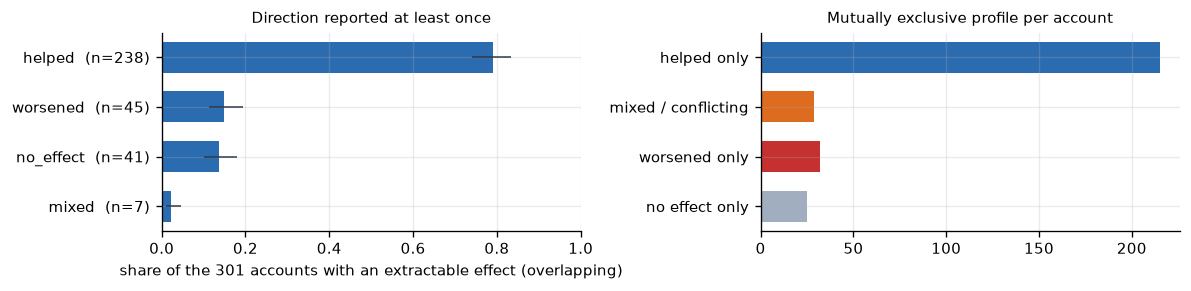

record level 'helped'  0.768  Wilson [0.732, 0.801]  n=569 records   ← ignores clustering, interval too narrow
record level 'helped'  0.768  reporter-clustered [0.708, 0.823]
account level          0.791  Wilson [0.741, 0.833]  n=301 accounts  ← the headline


In [13]:
e = f.effects
by_rep = e.groupby("reporter").direction.agg(
    any_helped=lambda s: (s == "helped").any(),
    any_worsened=lambda s: (s == "worsened").any(),
    any_no_effect=lambda s: (s == "no_effect").any(),
    any_mixed=lambda s: (s == "mixed").any(),
    n=("size"))
EFF_N = len(by_rep)

rows = []
for col, label in [("any_helped", "helped"), ("any_worsened", "worsened"),
                   ("any_no_effect", "no_effect"), ("any_mixed", "mixed")]:
    k = int(by_rep[col].sum())
    est, lo, hi = G.wilson(k, EFF_N)
    rows.append({"direction": label, "accounts": k, "rate": est,
                 "ci_lo": lo, "ci_hi": hi})
dm = pd.DataFrame(rows)
display(dm.round(3))

profile = by_rep.apply(
    lambda r: "helped only" if r.any_helped and not (r.any_worsened or r.any_no_effect or r.any_mixed)
    else "worsened only" if r.any_worsened and not (r.any_helped or r.any_no_effect or r.any_mixed)
    else "no effect only" if r.any_no_effect and not (r.any_helped or r.any_worsened or r.any_mixed)
    else "mixed / conflicting", axis=1)
display(profile.value_counts().rename("accounts").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(10, 2.5))
G.ci_bars(axes[0], dm.direction.tolist(), dm.rate.tolist(), dm.ci_lo.tolist(),
          dm.ci_hi.tolist(), dm.accounts.tolist(), color=G.COLORS["accent"])
axes[0].set_xlim(0, 1)
axes[0].set_xlabel(f"share of the {EFF_N} accounts with an extractable effect (overlapping)")
axes[0].set_title("Direction reported at least once", fontsize=9)

pv = profile.value_counts().reindex(
    ["helped only", "mixed / conflicting", "worsened only", "no effect only"]).fillna(0)
axes[1].barh(np.arange(len(pv))[::-1], pv.values, height=0.62,
             color=[G.COLORS["helped"], G.COLORS["mixed"], G.COLORS["worsened"],
                    G.COLORS["no_effect"]])
axes[1].set_yticks(np.arange(len(pv))[::-1], pv.index)
axes[1].set_title("Mutually exclusive profile per account", fontsize=9)
plt.tight_layout(); plt.show()

k, n = int((e.direction == "helped").sum()), len(e)
pt, lo, hi = G.clustered_rate(e.assign(h=e.direction.eq("helped")), "h",
                              seed=G.seed_for("direction", "helped"))
est, wlo, whi = G.wilson(k, n)
print(f"record level 'helped'  {est:.3f}  Wilson [{wlo:.3f}, {whi:.3f}]  n={n} records"
      f"   ← ignores clustering, interval too narrow")
print(f"record level 'helped'  {pt:.3f}  reporter-clustered [{lo:.3f}, {hi:.3f}]")
print(f"account level          {dm.loc[0, 'rate']:.3f}  Wilson "
      f"[{dm.loc[0, 'ci_lo']:.3f}, {dm.loc[0, 'ci_hi']:.3f}]  n={EFF_N} accounts  ← the headline")

Only **301 accounts of the 640 reporting use** produce an extractable effect at all — the
other 339 say they take garlic without saying what it did. Of those 301, **215 (71%) report
nothing but improvement**, 32 nothing but worsening, 25 nothing but no effect, and 29 report
conflicting directions across their own events.

The three framings printed above give nearly the same point estimate and very different
intervals. The record-level Wilson interval is not merely narrower, it is **wrong**: it
assumes 569 independent observations when they come from 301 accounts. The account-level
Wilson figure is the headline; the clustered bootstrap is shown to demonstrate that the gap
is clustering rather than sample size.

A 71%-helped-only figure among self-selected posters who chose to describe an outcome is
close to uninterpretable as evidence about garlic. It is interpretable as a description of
what this community publishes.

## 5.3 What the effects were reported *about*

Free-text targets are mapped into closed symptom classes; anything unmatched stays in
`unclassified` and is reported rather than hidden. Targets are multilabel — "SOB, brain fog,
energy, heart rate" counts in four classes.

,effect records,accounts,% helped
symptom class,,,
general_unspecified,59,46,0.763
cardiovascular,52,36,0.827
infection_antimicrobial,43,31,0.814
pain,41,26,0.780
gut_gi,40,28,0.650
respiratory_ent,26,22,0.962
fatigue_pem,24,17,0.875
cognitive_mood,20,19,0.900
unclassified,13,13,0.615


effect records with a stated target: 253 of 569 (44%)


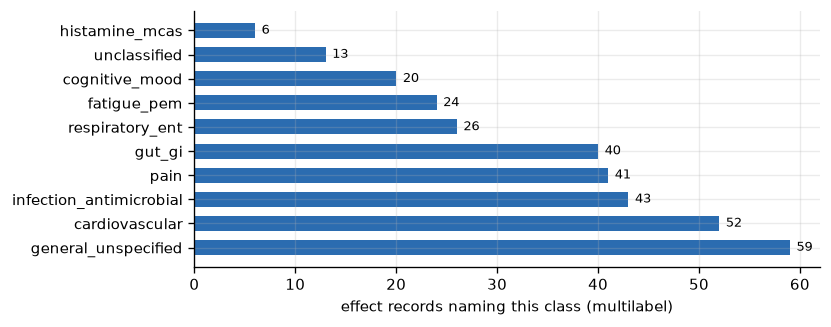

In [14]:
labelled = e[e.target.notna()]
sx = pd.DataFrame([
    {"symptom class": c,
     "effect records": int(labelled[f"sx_{c}"].sum()),
     "accounts": labelled.loc[labelled[f"sx_{c}"], "reporter"].nunique(),
     "% helped": labelled.loc[labelled[f"sx_{c}"], "direction"].eq("helped").mean()}
    for c in G.SYMPTOM_CLASSES]).set_index("symptom class")
sx = sx[sx["effect records"] > 0].sort_values("effect records", ascending=False)
display(sx.round(3))
print(f"effect records with a stated target: {len(labelled)} of {len(e)} "
      f"({len(labelled) / len(e):.0%})")

fig, ax = plt.subplots(figsize=(7.0, 2.8))
G.counts_bars(ax, sx.index.tolist()[::-1], sx["effect records"].tolist()[::-1],
              color=G.COLORS["accent"])
ax.set_xlabel("effect records naming this class (multilabel)")
plt.tight_layout(); plt.show()

Only 44% of effect records name a target at all, and the largest labelled class is
`general_unspecified` (59 records) — "overall", "all symptoms", "general well-being". Among
the classes that name something specific, **cardiovascular (52), antimicrobial (43), pain
(41) and gut/GI (40) lead** — the same registers the mechanism cut identified, now appearing
in what people say the garlic *did* rather than only what they say it *is for*.

The `% helped` column is printed per class and should not be read across rows. Every class
is far below a sample size where the differences between them would mean anything, no
contrast is tested, and the column inherits all the selection problems of §5.2.

## 5.4 Adverse events

The denominator is the 640 use-reporting accounts, and the three statuses are kept distinct.
`not_stated` is silence — it is the overwhelming majority and it is **not** evidence of
safety.

,status,accounts,denominator,rate,ci_lo,ci_hi
0,≥1 event with reported,106,640,0.166,0.139,0.196
1,≥1 event with explicit_none,18,640,0.028,0.018,0.044
2,no event carrying either (silence),521,640,0.814,NaN,NaN


,records,accounts
category,,
other,69,43
gi,46,38
odor,25,21
herx,14,12
histamine_flare,14,4
bleeding_or_anticoagulant,4,3
allergy,0,0


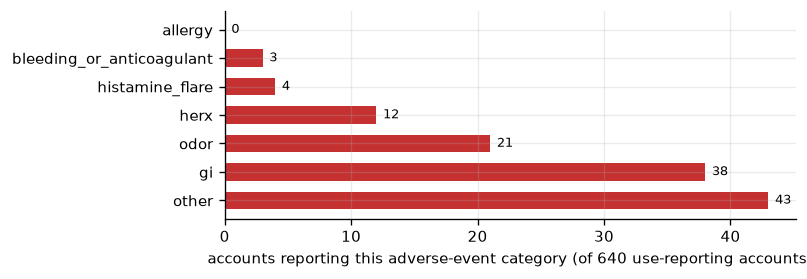

In [15]:
status = (use.groupby("reporter").adverse_event_status
          .agg(reported=lambda s: (s == "reported").any(),
               explicit_none=lambda s: (s == "explicit_none").any()))
rows = []
for col in ("reported", "explicit_none"):
    k = int(status[col].sum())
    est, lo, hi = G.wilson(k, USE_N)
    rows.append({"status": f"≥1 event with {col}", "accounts": k, "denominator": USE_N,
                 "rate": est, "ci_lo": lo, "ci_hi": hi})
silent = USE_N - int((status.reported | status.explicit_none).sum())
rows.append({"status": "no event carrying either (silence)", "accounts": silent,
             "denominator": USE_N, "rate": silent / USE_N, "ci_lo": np.nan, "ci_hi": np.nan})
display(pd.DataFrame(rows).round(3))

cats = (f.adverse.groupby("category")
        .agg(records=("claim_id", "size"), accounts=("reporter", "nunique"))
        .reindex(G.AE_CATEGORIES).fillna(0).astype(int)
        .sort_values("accounts", ascending=False))
display(cats)

fig, ax = plt.subplots(figsize=(6.8, 2.4))
G.counts_bars(ax, cats.index.tolist()[::-1], cats.accounts.tolist()[::-1],
              color=G.COLORS["worsened"])
ax.set_xlabel(f"accounts reporting this adverse-event category "
              f"(of {USE_N:,} use-reporting accounts)")
plt.tight_layout(); plt.show()

**106 of 640 use-reporting accounts (16.6%) report at least one adverse event; 18 (2.8%)
explicitly deny one; the remaining ~81% say nothing either way.** That last number is the
important one, and it is why this cannot be read as a side-effect rate: an adverse-event
percentage here is a share of extractable reports, never an incidence.

GI complaints (38 accounts) and odour (21) lead. Every category except `other` and `gi` sits
below the n ≥ 30 floor, so the category mix is descriptive only — notably
`bleeding_or_anticoagulant` at 3 accounts, despite anticoagulant language being a visible
*belief* register in §4 with 149 accounts. **People discuss garlic's blood-thinning
properties far more than they report bleeding from it.** That gap between mechanism talk and
experience reports is one of the cleaner illustrations of why belief and use had to be
separate payloads.

---
# 6. What the claims are anchored to

`cited_authority` is recorded only when the citation is about garlic specifically — a nearby
"my doctor" in a post that also mentions garlic does not qualify. DESIGN §4.6 flagged this
field as contaminated by exactly that failure mode (302 accounts had a `doctor` keyword in a
garlic document), so the low coverage here is the guard working, not a gap.

In [16]:
auth = claims[claims.cited_authority.notna()]
ca = (auth.groupby("cited_authority")
      .agg(claims=("claim_id", "size"), accounts=("reporter", "nunique"))
      .sort_values("accounts", ascending=False))
ca["% of belief-payload accounts"] = (ca.accounts / BELIEF_N).map("{:.1%}".format)
display(ca)
print(f"accounts citing any garlic-specific authority: {auth.reporter.nunique():,} "
      f"of {BELIEF_N:,} with a belief payload ({auth.reporter.nunique() / BELIEF_N:.1%})")

,claims,accounts,% of belief-payload accounts
cited_authority,,,
unspecified_authority,72,63,6.6%
study,50,35,3.7%
clinician,48,32,3.4%
community,33,31,3.3%
named_protocol,7,7,0.7%


accounts citing any garlic-specific authority: 156 of 950 with a belief payload (16.4%)


Only 156 of 950 belief-carrying accounts (16.4%) cite anything at all, and the largest
single bin is `unspecified_authority` (63 accounts). Clinicians (32) and studies (35) are
named at similar, small rates. **Garlic belief in this community is overwhelmingly
uncited** — asserted rather than sourced — which is consistent with folk-medicine
transmission and inconsistent with the protocol-driven picture the `named_protocol` bin
(7 accounts) would suggest.

---
# 7. How stable is any of this?

Stage 5b re-ran 50 already-complete units into a separate output database. Same `run_id`,
cold response cache, genuinely new provider calls, temperature 0.

**This is a floor on instability, not a full re-elicitation.** At temperature 0 it measures
residual provider nondeterminism only — the same prompt, the same spec, a different day. A
true test-retest would need a different sampling seed, which would move `run_id` and change
what was being measured.

,n
units complete in both,38
units attempted on repeat,50
units failed or unfinished on repeat,12
claim pairs,68
unmatched claims (full run),0
unmatched claims (repeat),1


,metric,n,of,rate
0,top-level field set identical,52,68,0.765
1,shared top-level values equal,541,609,0.888
2,all shared fields equal identical,21,68,0.309
3,speech_act identical,54,68,0.794
4,subject identical,61,68,0.897
5,exposure_status identical,61,68,0.897
6,polarity identical,53,68,0.779
7,preparation identical,63,68,0.926


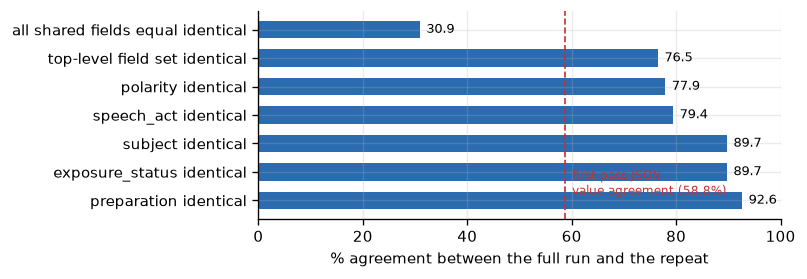

In [17]:
agree, ctx = G.repeat_agreement()
display(pd.Series(ctx).rename("n").to_frame())
display(agree.round(3))

fig, ax = plt.subplots(figsize=(6.8, 2.4))
sub = agree[agree.metric.str.contains("identical")].sort_values("rate")
G.counts_bars(ax, sub.metric.tolist(), (100 * sub.rate).round(1).tolist(),
              color=G.COLORS["accent"])
ax.set_xlim(0, 100); ax.set_xlabel("% agreement between the full run and the repeat")
ax.axvline(58.8, color="#c53030", lw=1, ls="--")
ax.annotate("first-pass JSON\nvalue agreement (58.8%)", (58.8, 0.2), xytext=(4, 0),
            textcoords="offset points", fontsize=7, color="#c53030")
plt.tight_layout(); plt.show()

On the 38 units that completed in both passes, this extraction is **more** stable than the
first-pass JSON records it is meant to improve on: 76.5% identical field sets against 36.5%,
and 88.8% agreement on shared values against 58.8%.

Two things keep that from being reassurance:

* **`speech_act` — the study's primary axis — moved on 14 of 68 paired claims (79.4%
  agreement).** The headline speech-act shares in §3 carry that instability, and the
  three-way `food_list` / `avoidance` / `culinary` block on this sample is far too small to
  characterise (a handful of swaps, including one in each direction between `food_list` and
  `avoidance`).
* **12 of the 50 repeat units did not complete** — 11 exhausted their retries and 1 was
  stopped by hand. Completers being stable says nothing about the units that could not be
  completed twice, and those are plausibly the harder ones.

---
# 8. Illustrative excerpts

The quote-free constraint on this notebook was relaxed on the understanding that these
fields are paraphrases. **§2.1 shows they are largely not.** Everything printed below should
be read as source text:

| Field sampled below | Contiguous verbatim | Grounding floor |
|---|---|---|
| `doses` quote | 82% | 0.5 bag-of-words |
| `adverse_events` quote | 81% | 0.5 bag-of-words |
| `effects` quote | 71% | 0.5 bag-of-words |
| `doses.raw_text` | **91%** | **none** |
| `adverse_events.raw_event` | **65%** | **none** |

The free-text fields in the lower half of that table were, in an earlier draft of this
notebook, printed under the heading "model-written summary fields (not quotes)" as though
they were the safer option. They are not — `doses.raw_text` is the most literal field in the
extraction. That framing is corrected here.

They are shown at all because the amount and adverse-event strings carry information the
enum bins cannot, and because the user relaxed the constraint deliberately. Every excerpt is
short, deduplicated, sampled deterministically, and carries **no account id, no hash, and no
link to any other figure in this notebook**. But the honest description is short unlinked
excerpts of Reddit text, not paraphrases — which is the fact that matters when deciding
whether this notebook can be committed. DESIGN §11 records that decision as open.

In [18]:
for field, label in [("doses", "stated amounts"),
                     ("adverse_events", "adverse events"),
                     ("effects", "reported effects")]:
    print(f"── {label} ({field}) " + "─" * 40)
    for q in G.sample_quotes(field, n=8, seed=G.seed_for(field)):
        print("   ", q)
    print()

# Free-text payload fields. NOT safer than the quotes above -- see §2.1.
# `effects.target` is deliberately omitted: it is the one free-text field the
# analysis computes on (§5.3), and it is shown there only as closed symptom
# classes, so printing the raw strings here would undo that.
rng = np.random.default_rng(G.seed_for("raw_event"))
raw_events = sorted(f.adverse.raw_event.dropna().unique())
print("── free-text adverse-event descriptions (65% verbatim, no grounding floor) "
      + "─" * 4)
for i in sorted(rng.choice(len(raw_events), size=8, replace=False)):
    print("   ", raw_events[i])

── stated amounts (doses) ────────────────────────────────────────
    2 garlic cloves per day
    2 teaspoons in the am
    4 raw cloves daily
    a bunch of garlic
    adding a small amount of yogurt and garlic
    allicin 720mg per day
    just do 3-5 for now
    one clove

── adverse events (adverse_events) ────────────────────────────────────────
    I feel a bit of herx
    I reek
    Stinky but i guess lifesaving
    giving me heart burn
    initial discomfort, can irritate a sensitive gut
    platelets went from 180 to 160
    prickly itchy
    wasn't pleasant

── reported effects (effects) ────────────────────────────────────────
    Cured fully in about a week for hydrogen SIBO
    I find this helps the most
    a lot of my symptoms go away
    a month
    found raw garlic to be very helpful
    helped a bit with bloating
    never felt much of a difference
    noticed significant improvements in energy and cognition

── free-text adverse-event descriptions (65% verbatim, no 

---
# 9. Limitations, cost, and what to check first

## What this run cost

| | |
|---|---|
| Realized provider cost | **$6.99** over 6,015 attempts carrying usage |
| Of which accepted attempts | $2.18 (31%) |
| Of which rejected attempts | $4.81 (69%) |
| Billing-uncertain attempts, excluded | 72 (this run) |
| Tokens | 23.5M in / 20.9M out, of which 17.8M reasoning (85% of output) |
| HTTP read timeout in force | connect=10, read=90, write=90, pool=60 |

The 25 billing-uncertain attempts from the original `TypeError` failure belong to a
different, stale `run_id` and are not counted here.

## Limitations that bound every figure above

1. **GATE 4 (b) did not clear.** 5/12 agreement on the `food_list` / `avoidance` /
   `culinary` block, human adjudication deferred, GATE 4 marked complete by decision rather
   than by result. The §3 speech-act shares are the study's headline and rest on this.
2. **Speech-act instability.** 79.4% repeat agreement on the primary axis.
3. **Retrieval recall gaps, accepted by design.** Emoji-only posts (🧄, 8 accounts) and bare
   `allium` without garlic (15 comments) are outside the FTS query and were deliberately not
   chased.
4. **Six units failed permanently** and one cohort account has no complete unit. The
   failures were long packed units, so the loss is not random with respect to how much a
   person wrote.
5. **The quote contract does not do what its name implies** (§2.1).
6. **Self-selected posters.** People who post about garlic are not people who use garlic,
   and both differ from people with long COVID.
7. **No chronology.** Timestamps are not loaded and duration exists only where an author
   stated it.
8. **Silence is not absence** anywhere in this notebook — most sharply for adverse events,
   where ~81% of use-reporting accounts say nothing either way.

## What is worth validating first

In descending order of how much rests on it:

1. **The `food_list` / `avoidance` / `culinary` boundary**, on the 9-row disagreement queue
   already prepared for human adjudication. Three of this study's headline numbers move
   together if that boundary is wrong, and it is the one place a prior pass is known to have
   erred badly (302 against a true 10–37).
2. **The cardiovascular pro-use finding** (§4.1) — 149 accounts against a 70-account prior,
   with polarity running the opposite way to the design's expectation. It is the most
   substantive new claim here and it has never been checked by hand.
3. **`unspecified_form` at 52% of use reporters** (§5). If a meaningful share of those are
   recoverable from text the model declined to commit on, the preparation mix changes shape.

## What must not be done with this database

Dose-response, efficacy, incidence, or any contrast presented as a test. Merging claims
across the four `run_id`s stored in this file. Re-running with a lowered grounding floor to
reduce the retry bill — the 0.5 floor is the only fabrication guard in the pipeline.